In [ ]:
!pip install pgmpy
!pip install daft

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


# Modeling Interventions with a Causal Directed Graphical Model

We model idea interventions in a causal DAG with graph mutilation.  We can accomplish this with the [`do`](http://pgmpy.org/base.html#pgmpy.models.DynamicBayesianNetwork.DAG.do) method in pgmpy.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

from pgmpy.factors.discrete.CPD import TabularCPD
from pgmpy.inference import VariableElimination
from pgmpy.models import BayesianNetwork as bn
from pgmpy.base import DAG

In [ ]:
# Build the causal DAG.
DAG = bn()
DAG.add_edges_from(
    [
      ('A','E'),
      ('S','E'),
      ('E','O'),
      ('E','R'),
      ('O','T'),
      ('R','T')
    ]
)

We'll simulate an intervention where we set education `"E"` to `"uni"`.

First, let's apply graph mutilation.  Visualize the graph before and after graph mutilation.

<Axes: >

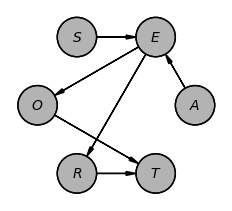

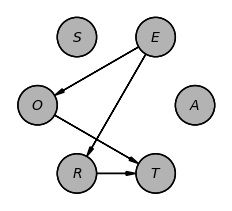

In [ ]:
DAG.to_daft().render()

mutilated_DAG = DAG.do("E")
mutilated_DAG.to_daft().render()

Now we convert the mutilated DAG into a directed graphical model by fitting the parameters on data.

In [ ]:
survey_url = "https://raw.githubusercontent.com/altdeep/causalML/master/datasets/transportation_survey.csv"
data = pd.read_csv(survey_url)

A naive approach is to just fit the graph on the data as usual.

In [ ]:
mutilated_DAG.fit(data)

But this will just estimate the parameters of `E` based on the proportions of high school and university education levels in the data.

In [ ]:
print(mutilated_DAG.get_cpds("E"))

+---------+------+
| E(high) | 0.58 |
+---------+------+
| E(uni)  | 0.42 |
+---------+------+


That's not what we want.  The ideal intervention should 100% probability on the `"uni"` outcome.  To do that, we have to artificially set the conditional probability distribution for `E` such that all the probability is on `"uni"`.

In [ ]:
cpd = TabularCPD('E', 2, [[1.0],[0.0]], state_names={"E":["high", "uni"]})
mutilated_DAG.add_cpds(cpd)
print(mutilated_DAG.get_cpds("E"))

+---------+---+
| E(high) | 1 |
+---------+---+
| E(uni)  | 0 |
+---------+---+


You can answer intervention queries using probabilistic inference on this generative *intervention* model.

Let's confirm that P(S|do(E="uni")) and P(S|E="uni") are different.

In [ ]:
DAG.fit(data)
inference = VariableElimination(DAG)
intervention_inference = VariableElimination(mutilated_DAG)
print("P(S|E='uni'):")
print(inference.query(variables=['S'], evidence={'E': "uni"}))
print("\n")
print("P(S|do(E='uni')):")
print(intervention_inference.query(variables=['S'], evidence={'E': "uni"}))

P(S|E='uni'):
+------+----------+
| S    |   phi(S) |
+======+==========+
| S(F) |   0.7584 |
+------+----------+
| S(M) |   0.2416 |
+------+----------+


P(S|do(E='uni')):
+------+----------+
| S    |   phi(S) |
+======+==========+
| S(F) |      nan |
+------+----------+
| S(M) |      nan |
+------+----------+


/usr/local/lib/python3.9/dist-packages/pgmpy/factors/discrete/DiscreteFactor.py:478: RuntimeWarning: invalid value encountered in true_divide
  phi.values = phi.values / phi.values.sum()


Note that we could have skipped the step of manually setting the causal Markov kernel of `"E"` and just relied on the `evidence` argument of the `query` method to set the intervention value for us.  However, the way we did it is more aligned with the definition of ideal intervention.  